# No-BESS vs BESS-Included Runs: Supervisor Deck Analysis

Produces the figures and tables for all 19 slides of the supervisor checklist deck, in
presentation order: run design, model configuration, inputs, model validation, results,
and limitations.

**Before running:**
- Set `RUN_A_PATH` / `RUN_B_PATH` in the config cell to your solved network files (`.nc`).
- Fill in every `# TODO` in the config cell with your actual Chapter 4/5 values, this
  notebook does not invent numbers for you, especially in Section 9 (Validation), where the
  observed comparison values must come from your primary sources, not be assumed.
- Confirm `BESS_CARRIER`, `EXISTING_BESS_NAMES`, `VRE_CARRIERS`, `THERMAL_CARRIERS` match your
  model's actual naming.
- **Check your BESS component representation** (`StorageUnit` vs `Store`+`Link`) in Section 10,
  before trusting anything about optimal BESS size/duration downstream.
- Section 2 auto-detects myopic multi-period vs single-period setup from
  `n.investment_periods`, if that comes back wrong, your model's investment period
  configuration differs from what this notebook assumes, fix the detection logic before
  trusting Section 14 (Energy Mix Over Time) or Section 18 (2050 map).


## 0. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

%matplotlib inline

# --- Thesis palette & figure style (keeps figures legible when exported to PDF) ---
PALETTE = {
    "blue_teal": "#0B4F6C",
    "amber": "#E8A33D",
    "slate": "#4A6572",
    "burgundy": "#7A3B46",
    "green": "#4B7A63",
}
RUN_COLORS = {"Run A (no BESS)": PALETTE["slate"], "Run B (BESS included)": PALETTE["blue_teal"]}

# carrier -> color, extend this to match every carrier in your model
CARRIER_COLORS = {
    "solar": PALETTE["amber"],
    "onwind": PALETTE["green"],
    "CCGT": PALETTE["slate"],
    "gas": PALETTE["slate"],
    "oil": PALETTE["burgundy"],
    "coal": "#2F2F2F",
    "lignite": "#8B5E3C",
    "biomass": "#7A9E7E",
    "battery": PALETTE["blue_teal"],
    "hydro": "#4FA5C4",
}
def color_for(carrier):
    return CARRIER_COLORS.get(carrier, "#999999")

def geo_bounds(n, pad_frac=0.08):
    '''Bounding box for buses with plausible lon/lat coordinates. Sector-coupling buses
    (e.g. an export bus in a projected CRS, or a co2-atmosphere bus with NaN coords) are
    excluded so a single outlier bus doesn't blow up the map extent and collapse the real
    network to a single point.'''
    xy = n.buses[["x", "y"]]
    valid = xy.notna().all(axis=1) & xy["x"].between(-180, 180) & xy["y"].between(-90, 90)
    xmin, xmax = xy.loc[valid, "x"].min(), xy.loc[valid, "x"].max()
    ymin, ymax = xy.loc[valid, "y"].min(), xy.loc[valid, "y"].max()
    xpad = (xmax - xmin) * pad_frac or 1.0
    ypad = (ymax - ymin) * pad_frac or 1.0
    return (xmin - xpad, xmax + xpad), (ymin - ypad, ymax + ypad)

def electricity_links(n):
    '''Links that output real electricity to an AC bus, i.e. the actual power-plant capacity
    in a sector-coupled model (e.g. CCGT/oil/coal converting a fuel bus to AC). The raw
    fuel-supply Generator on the other side of these (carrier "gas"/"oil"/"coal"/...) is just
    a commodity-market feed, not installed electrical MW, and is deliberately NOT counted as
    generation capacity anywhere below. Excludes the BESS charger/discharger links, which are
    accounted for separately via get_bess_representation().'''
    if not len(n.links):
        return n.links
    bus1_carrier = n.buses["carrier"].reindex(n.links["bus1"]).values
    is_ac_output = bus1_carrier == "AC"
    is_bess = n.links["carrier"].isin(["battery charger", "battery discharger"])
    return n.links[is_ac_output & ~is_bess]

def capacity_by_carrier(n):
    '''Optimal/installed ELECTRICAL capacity by technology, combining:
    - Generators that connect directly to an AC bus (e.g. solar, onwind). Raw fuel-supply
      Generators (gas/oil/coal/... sitting on a fuel bus) are excluded, they are not
      installed electrical capacity.
    - StorageUnits (e.g. hydro), otherwise silently missing since they aren't Generators.
    - electricity_links() (e.g. CCGT, oil, coal power plants), where the real electrical
      capacity for these technologies actually lives in a sector-coupled model.'''
    g = n.generators[~n.generators.carrier.isin(NON_PHYSICAL_CARRIERS)]
    g = g[n.buses["carrier"].reindex(g["bus"]).values == "AC"]
    cap = g.p_nom_opt.where(g.p_nom_extendable, g.p_nom).groupby(g.carrier).sum()

    if len(n.storage_units):
        su = n.storage_units
        su_cap = su.p_nom_opt.where(su.p_nom_extendable, su.p_nom).groupby(su.carrier).sum()
        cap = cap.add(su_cap, fill_value=0)

    elink = electricity_links(n)
    if len(elink):
        elink_cap = elink.p_nom_opt.where(elink.p_nom_extendable, elink.p_nom).groupby(elink.carrier).sum()
        cap = cap.add(elink_cap, fill_value=0)

    return cap

def generation_by_carrier(n):
    '''Electrical dispatch by technology, same component coverage as capacity_by_carrier():
    AC-connected Generators, StorageUnits, and electricity_links() (using -p1, the actual
    electricity delivered to the AC bus, not p0 which is fuel/H2 withdrawn on the input side).'''
    g = n.generators
    g_ac = g[n.buses["carrier"].reindex(g["bus"]).values == "AC"]
    parts = [n.generators_t.p[g_ac.index].T.groupby(g_ac.carrier).sum().T]

    if len(n.storage_units):
        su = n.storage_units
        parts.append(n.storage_units_t.p.T.groupby(su.carrier).sum().T)

    elink = electricity_links(n)
    if len(elink):
        elec_out = -n.links_t.p1[elink.index]
        parts.append(elec_out.T.groupby(elink.carrier).sum().T)

    gen = pd.concat(parts, axis=1)
    return gen.T.groupby(level=0).sum().T

plt.rcParams.update({
    "figure.dpi": 100,        # on-screen
    "savefig.dpi": 300,       # export resolution for LaTeX/slide figures
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": True,
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def savefig(fig, name):
    '''Save at 300 DPI with a tight bounding box, ready for slide/LaTeX use.'''
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved {path}")


In [2]:
# --- File paths ---
RUN_A_PATH = r"results/no_bess/postnetworks/elec_s_24_ec_lv1.0_1h_336seg_2050_0.071_AB_0export.nc"   # restricted: BESS not investable, existing BESS excluded
RUN_B_PATH = r"results/bess/postnetworks/elec_s_24_ec_lv1.0_1h_336seg_2050_0.071_AB_0export.nc"   # unrestricted: BESS power/energy/duration/siting optimized

# --- Model conventions ---
BESS_CARRIER = "battery"

# VRE_CARRIERS, THERMAL_CARRIERS, EXISTING_BESS_NAMES, and FUEL_PRICE are NOT hardcoded here,
# they're derived directly from the solved networks once n_a/n_b are loaded (see Section 1),
# since PyPSA-Earth already encodes this information: time-varying p_max_pu identifies VRE,
# non-extendable capacity identifies existing/committed assets, and generator marginal_cost
# on the raw fuel-supply generators already IS the fuel price. Hardcoding these risked drifting
# out of sync with the actual network (as happened here: "wind" vs "onwind", and a guessed gas
# CO2 factor that was 2x the model's own embedded value, see Section 16).

# Feasibility-slack generators PyPSA-Earth adds at every bus (electrical and otherwise) to
# guarantee the LP stays feasible. Very high marginal cost, essentially never dispatched in
# practice, capacity is a fixed safety-valve nameplate, not a real technology choice, exclude
# from capacity maps/tables so they don't visually dominate. Still checked properly, via actual
# dispatch rather than nameplate, in Section 17 Reliability.
NON_PHYSICAL_CARRIERS = ["load shedding"]

# --- Economic & policy parameters (Chapter 5 framework) --- TODO: replace with your actual values
SOC_DISCOUNT_RATE = 0.06
STP_DISCOUNT_RATE = 0.04
DISCOUNT_RATE = SOC_DISCOUNT_RATE
APPRAISAL_YEARS = 20
VOLL = 1000                          # currency / MWh. NOTE: this is YOUR Ch.5 economic value of
                                      # lost load for the appraisal, NOT the same thing as the
                                      # model's internal load-shedding penalty cost (a numerical
                                      # feasibility slack, ~1e6 currency/MWh, checked properly in
                                      # Section 17, and essentially never dispatched). Don't
                                      # conflate the two, they answer different questions.
DEMAND_GROWTH_PCT = 4.0              # % per year, from Ch. 4/5 demand projection
CARBON_PRICE = 0                     # currency / tCO2, 0 if not applying a shadow price
                                      # (confirmed: no CO2 budget/price global_constraint is
                                      # active in this solved network, so 0 is consistent)
SHADOW_EXCHANGE_RATE_PREMIUM = 0.0   # e.g. 0.10 for a 10% premium over the official rate

# --- Model validation targets --- TODO: fill in from your primary sources (Ch. 4), do not guess
OBSERVED_PEAK_DEMAND_MW = None
OBSERVED_GENERATION_MIX_PCT = {
    # "hfo": None, "diesel": None, "solar": None, "hydro_imports": None, ...
}


## 1. Run Design & Scenario Definition

Slide 1. Loads both networks, confirms they are identical except for BESS availability, and
reports which BESS assets are fixed in both runs (existing/committed) versus only buildable
in Run B.

In [3]:

n_a = pypsa.Network(RUN_A_PATH)
n_b = pypsa.Network(RUN_B_PATH)

print("Run A snapshots:", len(n_a.snapshots), "| Run B snapshots:", len(n_b.snapshots))
assert list(n_a.snapshots) == list(n_b.snapshots), "Snapshots differ between runs, check the model configs."

demand_a = n_a.loads_t.p_set.sum(axis=1)
demand_b = n_b.loads_t.p_set.sum(axis=1)
demand_diff = (demand_a - demand_b).abs().max()
print(f"Max hourly demand difference between runs: {demand_diff:.4f} MW")
if demand_diff > 1e-6:
    print("WARNING: demand differs between Run A and Run B, the comparison is no longer ceteris paribus.")

# Modelled year, parsed from the file paths, so every plot title below can say which year
# it's showing rather than leaving that implicit. Both runs must be the same year, otherwise
# the whole ceteris-paribus comparison is meaningless.
import re
def _extract_year(path):
    m = re.search(r"_(20[2-6]\d)_", str(path))
    if not m:
        raise ValueError(f"Could not detect a 4-digit year in path: {path}")
    return int(m.group(1))

year_a, year_b = _extract_year(RUN_A_PATH), _extract_year(RUN_B_PATH)
assert year_a == year_b, f"Run A ({year_a}) and Run B ({year_b}) are for different years, not comparable."
RUN_YEAR = year_a
print(f"Modelled year (both runs): {RUN_YEAR}")

print("\n--- Run design summary ---")
print("Run A: BESS excluded as an investable technology.")
print("Run B: BESS power, energy, duration & siting optimized.")
print("(Existing/committed BESS presence is checked in the next cell, once EXISTING_BESS_NAMES is derived.)")


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2050_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2050_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Run A snapshots: 8760 | Run B snapshots: 8760
Max hourly demand difference between runs: 0.0000 MW
Modelled year (both runs): 2050

--- Run design summary ---
Run A: BESS excluded as an investable technology.
Run B: BESS power, energy, duration & siting optimized.
(Existing/committed BESS presence is checked in the next cell, once EXISTING_BESS_NAMES is derived.)


In [4]:

# --- Derive model conventions directly from the solved networks ---
# Done here rather than in the Section 0 config cell, since it needs n_a/n_b to exist.

def _generator_carriers_with_profile(n):
    profiled = n.generators_t.p_max_pu.columns
    g = n.generators.loc[n.generators.index.isin(profiled)]
    g = g[n.buses["carrier"].reindex(g["bus"]).values == "AC"]
    return set(g.carrier.unique())

profiled_carriers = _generator_carriers_with_profile(n_a) | _generator_carriers_with_profile(n_b)
VRE_CARRIERS = sorted(profiled_carriers - set(NON_PHYSICAL_CARRIERS))
print(f"VRE_CARRIERS (auto-detected, time-varying p_max_pu on an AC bus): {VRE_CARRIERS}")

# THERMAL_CARRIERS = actual generation TECHNOLOGIES, not raw fuel commodities. Derived from
# electricity_links() (Links converting a fuel/H2 bus into AC power, e.g. CCGT/oil/coal power
# plants). In this sector-coupled model a Generator named "gas"/"oil"/"coal" is only the raw
# fuel-supply feed (near-zero/meaningless as installed capacity), the real electrical MW lives
# on the conversion Link, see capacity_by_carrier()/generation_by_carrier() in Section 0.
THERMAL_CARRIERS = sorted(set(electricity_links(n_a).carrier.unique()) | set(electricity_links(n_b).carrier.unique()))
print(f"THERMAL_CARRIERS (auto-detected, AC-output conversion Links): {THERMAL_CARRIERS}")

# Fuel price: read straight off the raw fuel-supply Generators' marginal_cost (currency/MWh
# fuel input) -- a DIFFERENT set of carriers than THERMAL_CARRIERS above (fuel commodity, not
# generation technology). PyPSA-Earth already stores this directly, no assumption needed.
FUEL_CARRIERS = sorted(
    (set(n_a.generators.carrier.unique()) | set(n_b.generators.carrier.unique()))
    - set(VRE_CARRIERS) - set(NON_PHYSICAL_CARRIERS)
)
FUEL_PRICE = {}
for c in FUEL_CARRIERS:
    mc = n_b.generators.loc[n_b.generators.carrier == c, "marginal_cost"]
    if len(mc):
        FUEL_PRICE[c] = mc.mean()
print(f"FUEL_PRICE (auto-detected from fuel-supply generator marginal_cost): {FUEL_PRICE}")

# Existing/committed BESS: non-extendable battery Store/StorageUnit components, i.e. capacity
# the model already treats as built, rather than a candidate the optimizer is choosing.
def _existing_bess_names(n, carrier=BESS_CARRIER):
    names = []
    if len(n.storage_units):
        su = n.storage_units
        names += su.index[(su.carrier == carrier) & (~su.p_nom_extendable)].tolist()
    if len(n.stores):
        st = n.stores
        names += st.index[(st.carrier == carrier) & (~st.e_nom_extendable)].tolist()
    return names

EXISTING_BESS_NAMES = sorted(set(_existing_bess_names(n_a)) | set(_existing_bess_names(n_b)))
print(f"\nEXISTING_BESS_NAMES (auto-detected, non-extendable {BESS_CARRIER!r}): {len(EXISTING_BESS_NAMES)} found")
if EXISTING_BESS_NAMES:
    present_a = [b for b in EXISTING_BESS_NAMES if b in list(n_a.storage_units.index) + list(n_a.stores.index)]
    present_b = [b for b in EXISTING_BESS_NAMES if b in list(n_b.storage_units.index) + list(n_b.stores.index)]
    print(f"Existing/committed BESS present in Run A: {present_a}")
    print(f"Existing/committed BESS present in Run B: {present_b}")
else:
    print("No non-extendable BESS found in either run, check BESS_CARRIER matches your model.")


VRE_CARRIERS (auto-detected, time-varying p_max_pu on an AC bus): ['onwind', 'solar']
THERMAL_CARRIERS (auto-detected, AC-output conversion Links): ['CCGT', 'H2 Fuel Cell', 'coal', 'oil']
FUEL_PRICE (auto-detected from fuel-supply generator marginal_cost): {'biomass': 7.4171528712937755, 'coal': 9.564271366499737, 'gas': 24.577861357672578, 'lignite': 3.3091003622775594, 'oil': 52.921085762844534}

EXISTING_BESS_NAMES (auto-detected, non-extendable 'battery'): 6 found
Existing/committed BESS present in Run A: ['SN0 0 battery-2045', 'SN0 19 battery-2045']
Existing/committed BESS present in Run B: ['SN0 0 battery-2025', 'SN0 12 battery-2030', 'SN0 15 battery-2030', 'SN0 2 battery-2025']


## 2. Configuration Assumptions

Slide 2. Reports whether the model is set up as a single-period or myopic multi-period
least-cost expansion, so this can be stated plainly to supervisors before showing anything
built from it.

In [5]:

is_multi_period = len(n_b.investment_periods) > 1
print(f"Investment periods (Run B): {list(n_b.investment_periods)}")
print(f"Multi-period model: {is_multi_period}")
if is_multi_period:
    print("This reads as a myopic, multi-period least-cost expansion setup if each period was "
          "solved without foresight of later periods, confirm this matches your solve procedure, "
          "the network alone cannot distinguish myopic from perfect-foresight, both use the same "
          "investment_periods structure.")
else:
    print("Single investment period: capacity expansion is solved once, for one representative year.")

extendable_gens = n_b.generators.p_nom_extendable.sum()
print(f"\nExtendable generators: {extendable_gens} of {len(n_b.generators)}")
print("Objective sense: minimise total system cost (investment + operation), standard PyPSA formulation.")


Investment periods (Run B): []
Multi-period model: False
Single investment period: capacity expansion is solved once, for one representative year.

Extendable generators: 117 of 261
Objective sense: minimise total system cost (investment + operation), standard PyPSA formulation.


## 3. Generation Data

Slide 3. Technology and location of every generator, split into existing/committed capacity
versus candidate (extendable) capacity, plus a location map sized by capacity and colored by
carrier. `geomap=False` avoids a cartopy/internet dependency; set it to `True` with `cartopy`
installed if you want an actual coastline basemap.

In [6]:

def generator_table(n):
    g = n.generators.copy()
    g = g[~g.carrier.isin(NON_PHYSICAL_CARRIERS)]
    # Exclude raw fuel-supply Generators (gas/oil/coal/... on a fuel bus): they're a
    # commodity-market feed, not installed electrical capacity, that lives on the
    # corresponding electricity_links() Link instead.
    g = g[n.buses["carrier"].reindex(g["bus"]).values == "AC"]
    g["capacity_mw"] = g.p_nom_opt.where(g.p_nom_extendable, g.p_nom)
    g["status"] = np.where(g.p_nom_extendable, "candidate", "existing/committed")
    table = g[["bus", "carrier", "capacity_mw", "status"]]

    # Include StorageUnit-based generation (e.g. hydro), otherwise silently absent just
    # because it isn't a Generator.
    if len(n.storage_units):
        su = n.storage_units.copy()
        su["capacity_mw"] = su.p_nom_opt.where(su.p_nom_extendable, su.p_nom)
        su["status"] = np.where(su.p_nom_extendable, "candidate", "existing/committed")
        table = pd.concat([table, su[["bus", "carrier", "capacity_mw", "status"]]])

    # Include the AC-output conversion Links (e.g. CCGT/oil/coal power plants), this is
    # where their real electrical capacity actually lives, not the fuel-supply Generator.
    elink = electricity_links(n)
    if len(elink):
        el = elink.copy()
        el["capacity_mw"] = el.p_nom_opt.where(el.p_nom_extendable, el.p_nom)
        el["status"] = np.where(el.p_nom_extendable, "candidate", "existing/committed")
        el["bus"] = el["bus1"]
        table = pd.concat([table, el[["bus", "carrier", "capacity_mw", "status"]]])

    return table.sort_values(["carrier", "bus"])

gen_table_b = generator_table(n_b)
print(gen_table_b)
gen_table_b.to_csv(FIG_DIR / "generation_data_table.csv")
print(f"\nsaved {FIG_DIR / 'generation_data_table.csv'}")


                     bus carrier   capacity_mw              status
SN0 17 CCGT-2050  SN0 17    CCGT  1.292559e-07           candidate
SN0 17 CCGT-2025  SN0 17    CCGT  1.500000e+02  existing/committed
SN0 2 CCGT-2050    SN0 2    CCGT  1.287274e-07           candidate
SN0 2 CCGT-2020    SN0 2    CCGT  1.916667e+02  existing/committed
SN0 4 CCGT-2050    SN0 4    CCGT  1.286696e-07           candidate
...                  ...     ...           ...                 ...
SN0 5 solar-2050   SN0 5   solar  6.908062e-07           candidate
SN0 6 solar-2050   SN0 6   solar  4.492965e-07           candidate
SN0 7 solar-2050   SN0 7   solar  3.756205e-07           candidate
SN0 8 solar-2050   SN0 8   solar  5.683969e-07           candidate
SN0 9 solar-2050   SN0 9   solar  6.231800e-07           candidate

[96 rows x 4 columns]

saved figures/generation_data_table.csv


saved figures/generation_data_map.png


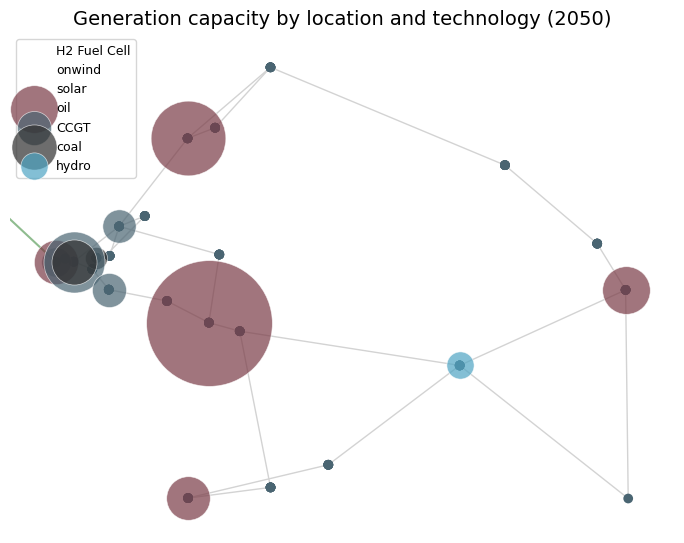

In [7]:

fig, ax = plt.subplots(figsize=(7, 7))
n_b.plot(ax=ax, geomap=False, bus_sizes=0.002, bus_colors=PALETTE["slate"],
         line_widths=1, line_colors="lightgrey")
ax.set_xlim(*geo_bounds(n_b)[0])
ax.set_ylim(*geo_bounds(n_b)[1])

cap_by_bus_carrier = gen_table_b.groupby(["bus", "carrier"])["capacity_mw"].sum()
for (bus, carrier), capval in cap_by_bus_carrier.items():
    if bus in n_b.buses.index and capval > 0:
        x, y = n_b.buses.loc[bus, ["x", "y"]]
        ax.scatter([x], [y], s=capval * 3, color=color_for(carrier), alpha=0.7,
                   edgecolors="white", linewidths=0.5, zorder=5, label=carrier)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=9)
ax.set_title(f"Generation capacity by location and technology ({RUN_YEAR})")
savefig(fig, "generation_data_map")
plt.show()


## 4. Transmission Map

Slide 4. Line widths scaled to capacity, buses labelled with nominal voltage where available.

                          x             y  v_nom
Bus                                             
SN0 0         -1.546640e+01  1.651120e+01  380.0
SN0 1         -1.603160e+01  1.416760e+01  380.0
SN0 10        -1.622270e+01  1.255780e+01  380.0
SN0 11        -1.622730e+01  1.585920e+01  380.0
SN0 12        -1.493570e+01  1.286320e+01  380.0
...                     ...           ...    ...
SN0 6 battery -1.331470e+01  1.561310e+01    1.0
SN0 7 battery -1.220710e+01  1.446820e+01    1.0
SN0 8 battery -1.593620e+01  1.479310e+01    1.0
SN0 9 battery -1.695020e+01  1.447050e+01    1.0
H2 export bus -1.942850e+06  1.811438e+06    1.0

[144 rows x 3 columns]


saved figures/transmission_map.png


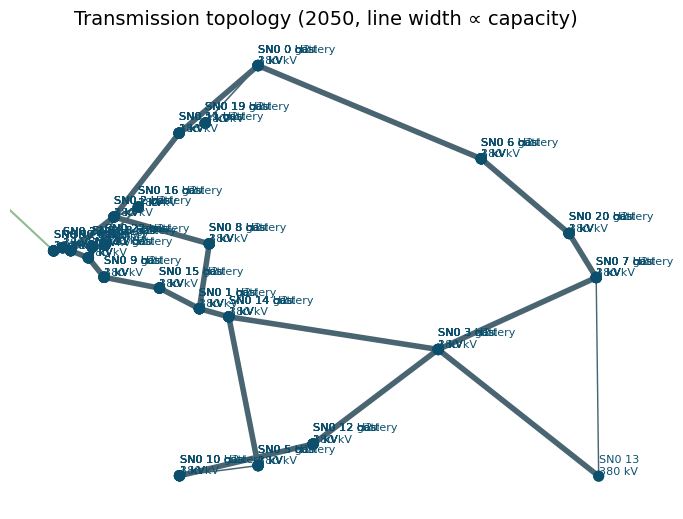

In [8]:

substation_table = n_b.buses[["x", "y", "v_nom"]].copy()
print(substation_table)
substation_table.to_csv(FIG_DIR / "substation_table.csv")

fig, ax = plt.subplots(figsize=(7, 7))
line_cap = n_b.lines.s_nom_opt.where(n_b.lines.s_nom_extendable, n_b.lines.s_nom)
line_widths = 1 + 3 * (line_cap / line_cap.max()) if len(line_cap) and line_cap.max() > 0 else 1.5
n_b.plot(ax=ax, geomap=False, bus_sizes=0.003, bus_colors=PALETTE["blue_teal"],
         line_widths=line_widths, line_colors=PALETTE["slate"])
xlim, ylim = geo_bounds(n_b)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
for bus, row in n_b.buses.iterrows():
    if xlim[0] <= row.x <= xlim[1] and ylim[0] <= row.y <= ylim[1]:
        ax.annotate(f"{bus}\n{row.v_nom:.0f} kV" if row.v_nom else bus, (row.x, row.y),
                    fontsize=8, ha="left", va="bottom", color=PALETTE["blue_teal"])
ax.set_title(f"Transmission topology ({RUN_YEAR}, line width ∝ capacity)")
savefig(fig, "transmission_map")
plt.show()


## 5. Input Data

Slide 5. Assembles the headline input assumptions into one table for the slide.

In [9]:

input_data = pd.DataFrame({
    "parameter": ["VoLL (currency/MWh)", "SOC discount rate", "STP discount rate",
                  "Demand growth (%/yr)", "Carbon price (currency/tCO2)",
                  "Shadow exchange rate premium"],
    "value": [VOLL, SOC_DISCOUNT_RATE, STP_DISCOUNT_RATE, DEMAND_GROWTH_PCT, CARBON_PRICE,
              SHADOW_EXCHANGE_RATE_PREMIUM],
})
fuel_price_rows = pd.DataFrame({
    "parameter": [f"Fuel price, {k} (currency/MWh)" for k in FUEL_PRICE],
    "value": list(FUEL_PRICE.values()),
})
input_data = pd.concat([input_data, fuel_price_rows], ignore_index=True)
print(input_data)
input_data.to_csv(FIG_DIR / "input_data_table.csv", index=False)

if input_data["value"].isna().any():
    print("\nWARNING: some input parameters are still None, fill these in from Ch. 5 before presenting.")


                             parameter        value
0                  VoLL (currency/MWh)  1000.000000
1                    SOC discount rate     0.060000
2                    STP discount rate     0.040000
3                 Demand growth (%/yr)     4.000000
4         Carbon price (currency/tCO2)     0.000000
5         Shadow exchange rate premium     0.000000
6   Fuel price, biomass (currency/MWh)     7.417153
7      Fuel price, coal (currency/MWh)     9.564271
8       Fuel price, gas (currency/MWh)    24.577861
9   Fuel price, lignite (currency/MWh)     3.309100
10      Fuel price, oil (currency/MWh)    52.921086


## 6. Typical Demand Profile

saved figures/demand_profile.png


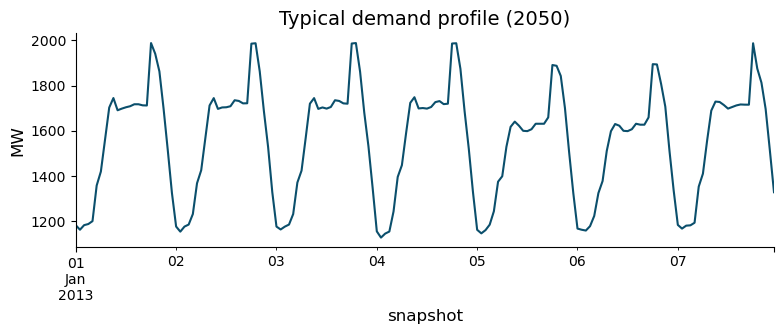

In [10]:

demand = n_b.loads_t.p_set.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 3.5))
if is_multi_period:
    demand.loc[demand.index.get_level_values("period")[0]].plot(ax=ax, color=PALETTE["blue_teal"])
else:
    demand.iloc[: min(len(demand), 24 * 7)].plot(ax=ax, color=PALETTE["blue_teal"])
ax.set_ylabel("MW")
ax.set_title(f"Typical demand profile ({RUN_YEAR})")
savefig(fig, "demand_profile")
plt.show()


## 7. Costs

Slide 7. CAPEX and variable OPEX read directly from the network. **Fixed OPEX (FOM)** is not
a standard PyPSA generator attribute, if it isn't already folded into `capital_cost` in your
model, add it as a separate column here, marked `# TODO` below.

In [11]:

def cost_table(n):
    g = n.generators.copy()
    df = pd.DataFrame({
        "carrier": g.carrier,
        "capex_per_mw": g.capital_cost,
        "var_opex_per_mwh": g.marginal_cost,
        # TODO: add fixed O&M per MW/year here if tracked separately from capital_cost
        # "fom_per_mw_year": ...,
    })
    return df

costs = cost_table(n_b)
print(costs)
costs.to_csv(FIG_DIR / "cost_table.csv")


                                   carrier  capex_per_mw  var_opex_per_mwh
Generator                                                                 
SN0 0 onwind-2050                   onwind  94128.969871      2.492008e-02
SN0 0 solar-2050                     solar  30129.873172      2.079263e-02
SN0 1 onwind-2050                   onwind  94128.969871      2.438026e-02
SN0 1 solar-2050                     solar  30129.873172      1.941241e-02
SN0 10 onwind-2050                  onwind  94128.969871      2.503368e-02
...                                    ...           ...               ...
SN0 6 battery load shedding  load shedding      0.000000      1.000000e+06
SN0 7 battery load shedding  load shedding      0.000000      1.000000e+06
SN0 8 battery load shedding  load shedding      0.000000      1.000000e+06
SN0 9 battery load shedding  load shedding      0.000000      1.000000e+06
H2 export bus load shedding  load shedding      0.000000      1.000000e+06

[261 rows x 3 columns]


## 8. Technical Assumptions

Slide 8. Efficiency and mean capacity factor by technology.

In [12]:

def technical_table(n):
    g = n.generators
    rows = []
    for name, row in g.iterrows():
        if name in n.generators_t.p_max_pu.columns:
            cf = n.generators_t.p_max_pu[name].mean()
        else:
            cf = 1.0
        rows.append({"name": name, "carrier": row.carrier, "efficiency": row.efficiency,
                     "mean_capacity_factor": cf})
    return pd.DataFrame(rows)

tech_table = technical_table(n_b)
print(tech_table)
tech_table.to_csv(FIG_DIR / "technical_assumptions_table.csv", index=False)


                            name        carrier  efficiency  \
0              SN0 0 onwind-2050         onwind         1.0   
1               SN0 0 solar-2050          solar         1.0   
2              SN0 1 onwind-2050         onwind         1.0   
3               SN0 1 solar-2050          solar         1.0   
4             SN0 10 onwind-2050         onwind         1.0   
..                           ...            ...         ...   
256  SN0 6 battery load shedding  load shedding         1.0   
257  SN0 7 battery load shedding  load shedding         1.0   
258  SN0 8 battery load shedding  load shedding         1.0   
259  SN0 9 battery load shedding  load shedding         1.0   
260  H2 export bus load shedding  load shedding         1.0   

     mean_capacity_factor  
0                0.269173  
1                0.173796  
2                0.124640  
3                0.163843  
4                0.093156  
..                    ...  
256              1.000000  
257              1.

## 9. Model Validation

Slide 9. Compares modelled generation mix and peak demand against observed values, per
Parzen et al.'s validation approach. **This only works once `OBSERVED_PEAK_DEMAND_MW` and
`OBSERVED_GENERATION_MIX_PCT` in the config cell are filled in from your primary sources.**
This notebook will not fabricate those numbers.

In [13]:

if OBSERVED_PEAK_DEMAND_MW is not None:
    modelled_peak = demand.max()
    print(f"Modelled peak demand: {modelled_peak:.1f} MW")
    print(f"Observed peak demand: {OBSERVED_PEAK_DEMAND_MW:.1f} MW")
    print(f"Difference: {100 * (modelled_peak - OBSERVED_PEAK_DEMAND_MW) / OBSERVED_PEAK_DEMAND_MW:+.1f}%")
else:
    print("Set OBSERVED_PEAK_DEMAND_MW in the config cell to run this check.")

if OBSERVED_GENERATION_MIX_PCT:
    # Uses generation_by_carrier(), not just n_b.generators_t.p, so StorageUnit-based
    # technologies (e.g. hydro) are included in the modelled mix, not silently dropped.
    gen_by_carrier = generation_by_carrier(n_b).sum()
    modelled_mix_pct = 100 * gen_by_carrier / gen_by_carrier.sum()
    compare = pd.DataFrame({
        "modelled_pct": modelled_mix_pct,
        "observed_pct": pd.Series(OBSERVED_GENERATION_MIX_PCT),
    })
    print("\n", compare)

    fig, ax = plt.subplots(figsize=(7, 4))
    compare.plot(kind="bar", ax=ax, color=[PALETTE["blue_teal"], PALETTE["amber"]])
    ax.set_ylabel("% of generation")
    ax.set_title(f"Validation: modelled vs observed generation mix ({RUN_YEAR})")
    savefig(fig, "validation_generation_mix")
    plt.show()
else:
    print("Set OBSERVED_GENERATION_MIX_PCT in the config cell to run this check.")


Set OBSERVED_PEAK_DEMAND_MW in the config cell to run this check.
Set OBSERVED_GENERATION_MIX_PCT in the config cell to run this check.


## 10. Optimal Capacity Built

Slide 10. BESS detection handles both `StorageUnit` and `Store`+`Link` representations,
**check the printed output before trusting anything downstream.** Also reports the capacity
substitution ratio and whether BESS unlocks additional VRE capacity in Run B.

In [14]:

def get_bess_representation(n, carrier=BESS_CARRIER):
    '''Detect and summarise the BESS technology in a solved network. Returns None if absent.'''

    su_mask = n.storage_units.carrier.eq(carrier) if len(n.storage_units) else pd.Series(dtype=bool)
    if su_mask.any():
        names = n.storage_units.index[su_mask]
        power_mw = n.storage_units.loc[names, "p_nom_opt"].sum()
        energy_mwh = (n.storage_units.loc[names, "p_nom_opt"] * n.storage_units.loc[names, "max_hours"]).sum()
        dispatch = n.storage_units_t.p[names].sum(axis=1)
        soc = n.storage_units_t.state_of_charge[names].sum(axis=1)
        buses = n.storage_units.loc[names, "bus"].unique().tolist()
        return dict(kind="storage_unit", names=list(names), power_mw=power_mw,
                    energy_mwh=energy_mwh, dispatch=dispatch, soc=soc, buses=buses)

    store_mask = n.stores.carrier.eq(carrier) if len(n.stores) else pd.Series(dtype=bool)
    if store_mask.any():
        store_names = n.stores.index[store_mask]
        energy_mwh = n.stores.loc[store_names, "e_nom_opt"].sum()
        soc = n.stores_t.e[store_names].sum(axis=1)
        store_buses = set(n.stores.loc[store_names, "bus"])

        link_mask = n.links.bus1.isin(store_buses) | n.links.bus0.isin(store_buses)
        link_names = n.links.index[link_mask]
        power_mw = n.links.loc[link_names, "p_nom_opt"].max() if len(link_names) else np.nan

        charge = pd.Series(0.0, index=n.snapshots)
        discharge = pd.Series(0.0, index=n.snapshots)
        for l in link_names:
            flow = n.links_t.p0[l]
            if n.links.loc[l, "bus1"] in store_buses:
                charge += flow.clip(lower=0)
            else:
                discharge += (-flow).clip(lower=0)
        dispatch = discharge - charge
        buses = list(store_buses)
        return dict(kind="store_link", store_names=list(store_names), link_names=list(link_names),
                    power_mw=power_mw, energy_mwh=energy_mwh, dispatch=dispatch, soc=soc, buses=buses)
    return None


bess_a = get_bess_representation(n_a)
bess_b = get_bess_representation(n_b)

print("Run A BESS:", "none found (expected)" if bess_a is None else bess_a["kind"])
if bess_b is None:
    print("Run B: no BESS was built or detected, check BESS_CARRIER and rerun.")
else:
    duration_h = bess_b["energy_mwh"] / bess_b["power_mw"] if bess_b["power_mw"] else np.nan
    print(f"Run B BESS ({bess_b['kind']}): {bess_b['power_mw']:.1f} MW, "
          f"{bess_b['energy_mwh']:.1f} MWh, implied duration {duration_h:.2f} h")
    print("Sited at bus(es):", bess_b["buses"])


Run A BESS: store_link
Run B BESS (store_link): 40.0 MW, 714.8 MWh, implied duration 17.87 h
Sited at bus(es): ['SN0 17 battery', 'SN0 2 battery', 'SN0 7 battery', 'SN0 14 battery', 'SN0 12 battery', 'SN0 18 battery', 'SN0 16 battery', 'SN0 4 battery', 'SN0 5 battery', 'SN0 1 battery', 'SN0 6 battery', 'SN0 0 battery', 'SN0 10 battery', 'SN0 15 battery', 'SN0 20 battery', 'SN0 3 battery', 'SN0 22 battery', 'SN0 23 battery', 'SN0 8 battery', 'SN0 11 battery', 'SN0 9 battery', 'SN0 19 battery', 'SN0 21 battery']


              Run A (no BESS)  Run B (BESS included)
carrier                                             
CCGT              1185.000006            1185.000001
H2 Fuel Cell         0.000041               0.000003
coal               435.393260             435.393259
hydro              128.000000             128.000000
oil               4966.464836            4755.437294
onwind               0.000062               0.000004
solar                0.000191               0.000016


saved figures/capacity_mix_comparison.png


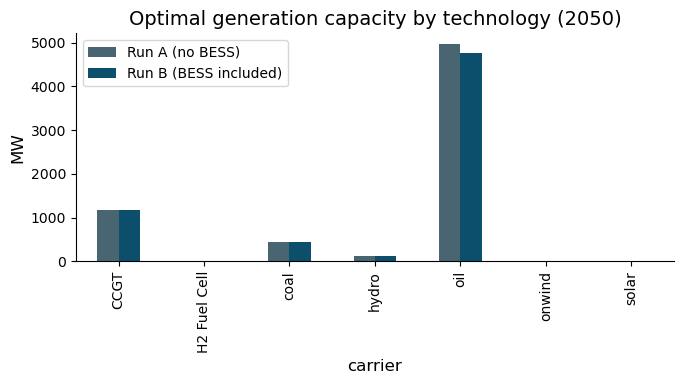


Thermal capacity avoided: 211.0 MW
Capacity substitution ratio: 5.28 MW thermal avoided per MW BESS built
onwind capacity change (Run B minus Run A): -0.0 MW
solar capacity change (Run B minus Run A): -0.0 MW


In [15]:

# capacity_by_carrier() is defined in Section 0, combines Generators and StorageUnits so
# hydro (a StorageUnit here) isn't silently missing from this comparison.
cap_a = capacity_by_carrier(n_a)
cap_b = capacity_by_carrier(n_b)
cap_compare = pd.DataFrame({"Run A (no BESS)": cap_a, "Run B (BESS included)": cap_b}).fillna(0)
print(cap_compare)

fig, ax = plt.subplots(figsize=(7, 4))
cap_compare.plot(kind="bar", ax=ax, color=[PALETTE["slate"], PALETTE["blue_teal"]])
ax.set_ylabel("MW")
ax.set_title(f"Optimal generation capacity by technology ({RUN_YEAR})")
savefig(fig, "capacity_mix_comparison")
plt.show()

thermal_avoided_mw = sum(max(cap_a.get(c, 0) - cap_b.get(c, 0), 0) for c in THERMAL_CARRIERS)
if bess_b is not None and bess_b["power_mw"]:
    substitution_ratio = thermal_avoided_mw / bess_b["power_mw"]
    print(f"\nThermal capacity avoided: {thermal_avoided_mw:.1f} MW")
    print(f"Capacity substitution ratio: {substitution_ratio:.2f} MW thermal avoided per MW BESS built")

for c in VRE_CARRIERS:
    if c in cap_a.index or c in cap_b.index:
        delta = cap_b.get(c, 0) - cap_a.get(c, 0)
        print(f"{c} capacity change (Run B minus Run A): {delta:+.1f} MW")


## 11. System Cost & Decision Metrics

Slide 11. If optimal BESS capacity came out near zero in Section 10, that is itself the
finding under your reference-case parameters, report it as such.

In [16]:

system_cost_a = n_a.objective
system_cost_b = n_b.objective
net_benefit_annual = system_cost_a - system_cost_b

print(f"Run A system cost: {system_cost_a:,.0f}")
print(f"Run B system cost: {system_cost_b:,.0f}")
print(f"Net system benefit (A - B): {net_benefit_annual:,.0f}")


Run A system cost: 88,215,796
Run B system cost: 87,852,745
Net system benefit (A - B): 363,051


In [17]:

def npv(rate, cashflows):
    return sum(cf / (1 + rate) ** t for t, cf in enumerate(cashflows))

def irr(cashflows, bracket=(-0.99, 5)):
    from scipy.optimize import brentq
    f = lambda r: npv(r, cashflows)
    try:
        return brentq(f, *bracket)
    except ValueError:
        return np.nan

if bess_b is not None and bess_b["kind"] == "store_link":
    bess_capex = (
        n_b.stores.loc[bess_b["store_names"], "capital_cost"].mul(
            n_b.stores.loc[bess_b["store_names"], "e_nom_opt"]).sum()
        + n_b.links.loc[bess_b["link_names"], "capital_cost"].mul(
            n_b.links.loc[bess_b["link_names"], "p_nom_opt"]).sum()
    )
elif bess_b is not None and bess_b["kind"] == "storage_unit":
    bess_capex = n_b.storage_units.loc[bess_b["names"], "capital_cost"].mul(
        n_b.storage_units.loc[bess_b["names"], "p_nom_opt"]).sum()
else:
    bess_capex = 0.0

print(f"Implied BESS CAPEX (year 0): {bess_capex:,.0f}")

cashflows = [-bess_capex] + [net_benefit_annual] * APPRAISAL_YEARS
result_npv = npv(DISCOUNT_RATE, cashflows)
result_irr = irr(cashflows)
pv_benefits = npv(DISCOUNT_RATE, [0] + [net_benefit_annual] * APPRAISAL_YEARS)
bcr = pv_benefits / bess_capex if bess_capex else np.nan

print(f"NPV @ {DISCOUNT_RATE:.1%}: {result_npv:,.0f}")
print(f"BCR: {bcr:.2f}")
print(f"EIRR: {result_irr:.1%}" if not np.isnan(result_irr) else "EIRR: does not break even at any feasible rate")


Implied BESS CAPEX (year 0): 6,334,894


NPV @ 6.0%: -2,170,733
BCR: 0.66
EIRR: 1.3%


## 12. Value-Stream Decomposition

Slide 12. Traceable back to your Chapter 5 benefit/cost categories, rather than a single
opaque net number. Some lines need model-specific wiring (marked `# TODO`).

Avoided fuel/variable cost by carrier (Run A minus Run B):
carrier
gas               45021.970395
oil                   0.311603
solar                 0.003682
onwind                0.001664
biomass               0.000000
lignite               0.000000
load shedding         0.000000
coal            -143618.941625
dtype: float64

Avoided generation capacity investment by carrier:
carrier
onwind     5.450990
solar      5.278743
biomass    0.000000
coal       0.000000
gas        0.000000
lignite    0.000000
oil        0.000000
dtype: float64

--- Running decomposition summary (fill in remaining rows) ---
Avoided fuel & variable cost             -9.859665e+04
Avoided generation capacity investment    1.072973e+01
BESS CAPEX (annualised, Run B)           -6.334894e+06
Name: value (currency), dtype: float64
saved figures/value_stream_decomposition.png


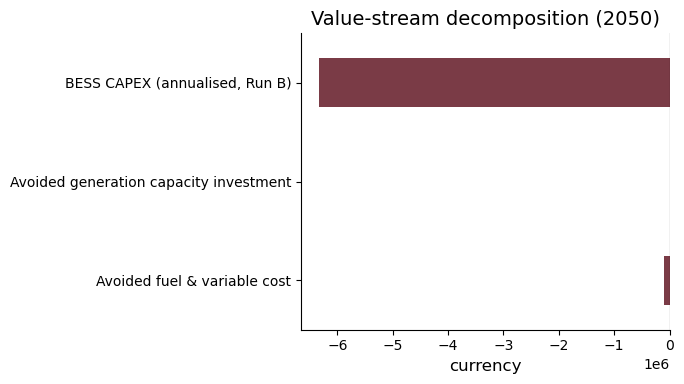

In [18]:

def generation_cost_by_carrier(n):
    g = n.generators
    cost = (n.generators_t.p * g.marginal_cost).sum(axis=0)
    return cost.groupby(g.carrier).sum()

cost_a = generation_cost_by_carrier(n_a)
cost_b = generation_cost_by_carrier(n_b)
all_carriers = cost_a.index.union(cost_b.index)
fuel_cost_avoided = cost_a.reindex(all_carriers, fill_value=0).sub(cost_b.reindex(all_carriers, fill_value=0))
print("Avoided fuel/variable cost by carrier (Run A minus Run B):")
print(fuel_cost_avoided.sort_values(ascending=False))

def capacity_investment(n):
    g = n.generators[n.generators.p_nom_extendable]
    return (g.p_nom_opt * g.capital_cost).groupby(g.carrier).sum()

capex_a = capacity_investment(n_a)
capex_b = capacity_investment(n_b)
all_c = capex_a.index.union(capex_b.index)
avoided_capacity_investment = capex_a.reindex(all_c, fill_value=0).sub(capex_b.reindex(all_c, fill_value=0))
print("\nAvoided generation capacity investment by carrier:")
print(avoided_capacity_investment.sort_values(ascending=False))

# TODO: avoided curtailment value (see Section 13), avoided unserved energy at VoLL (see
# Section 17), emissions value if a carbon price is applied (see Section 16)

summary = pd.Series({
    "Avoided fuel & variable cost": fuel_cost_avoided.sum(),
    "Avoided generation capacity investment": avoided_capacity_investment.sum(),
    "BESS CAPEX (annualised, Run B)": -bess_capex,
}, name="value (currency)")
print("\n--- Running decomposition summary (fill in remaining rows) ---")
print(summary)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [PALETTE["green"] if v >= 0 else PALETTE["burgundy"] for v in summary.values]
summary.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("currency")
ax.set_title(f"Value-stream decomposition ({RUN_YEAR})")
savefig(fig, "value_stream_decomposition")
plt.show()


## 13. Technical Dispatch Behaviour

Slide 13. Dispatch stack on representative days, plus BESS charge/discharge, state of
charge, cycling, and curtailment.

saved figures/dispatch_stack_representative_days.png


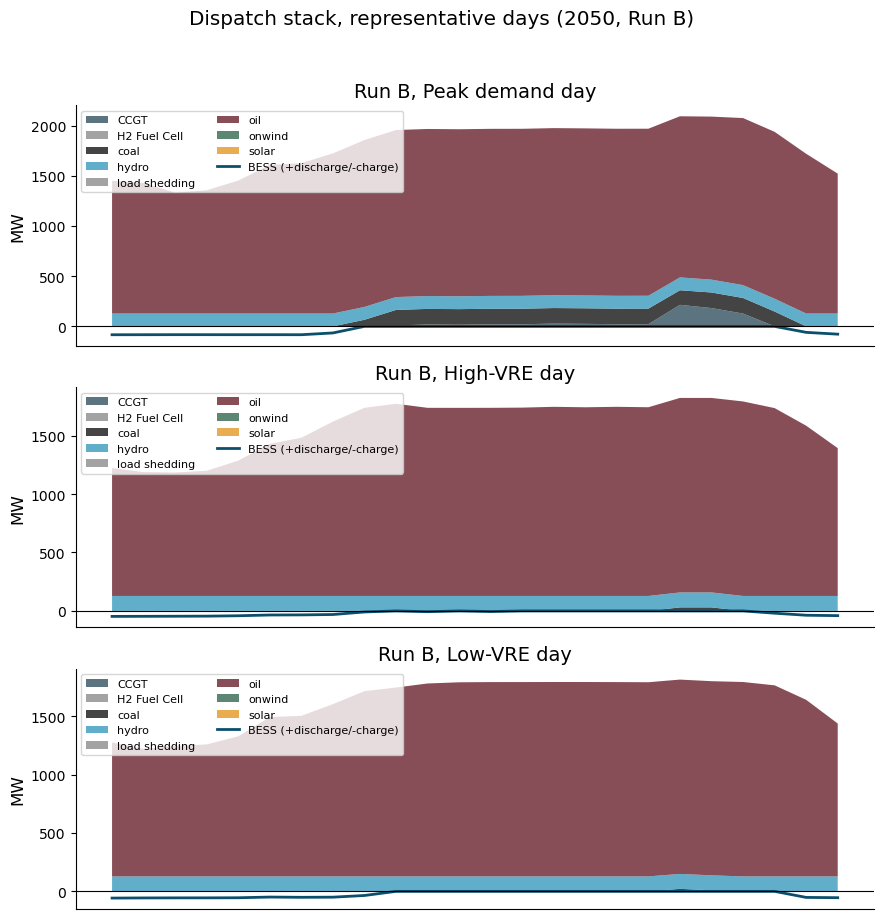

In [19]:

# generation_by_carrier() is defined in Section 0, combines Generators and StorageUnits so
# hydro (a StorageUnit here) appears in the dispatch stack instead of being silently dropped.
gen_a = generation_by_carrier(n_a)
gen_b = generation_by_carrier(n_b)

def plot_dispatch_stack(gen, bess_dispatch, day, title, ax):
    day_gen = gen.loc[day]
    colors = [color_for(c) for c in day_gen.columns]
    ax.stackplot(range(len(day_gen)), day_gen.values.T, labels=day_gen.columns, colors=colors, alpha=0.9)
    if bess_dispatch is not None:
        ax.plot(range(len(day_gen)), bess_dispatch.loc[day].values, color=PALETTE["blue_teal"],
                linewidth=2, label="BESS (+discharge/-charge)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("MW")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.set_xticks([])

demand_b_series = n_b.loads_t.p_set.sum(axis=1)
if is_multi_period:
    ref_period = max(n_b.investment_periods)
    demand_ref = demand_b_series.loc[ref_period]
    gen_b_ref = gen_b.loc[ref_period]
else:
    demand_ref = demand_b_series
    gen_b_ref = gen_b

peak_day = demand_ref.idxmax().normalize() if hasattr(demand_ref.idxmax(), "normalize") else demand_ref.idxmax()
vre_cols = [c for c in n_b.generators.index if n_b.generators.loc[c, "carrier"] in VRE_CARRIERS]
if vre_cols:
    vre_profile = n_b.generators_t.p_max_pu[vre_cols].mean(axis=1)
    vre_profile_ref = vre_profile.loc[ref_period] if is_multi_period else vre_profile
    high_vre_day = vre_profile_ref.idxmax()
    low_vre_day = vre_profile_ref.idxmin()
    if hasattr(high_vre_day, "normalize"):
        high_vre_day, low_vre_day = high_vre_day.normalize(), low_vre_day.normalize()
else:
    high_vre_day = low_vre_day = peak_day

days = {"Peak demand day": peak_day, "High-VRE day": high_vre_day, "Low-VRE day": low_vre_day}

fig, axes = plt.subplots(len(days), 1, figsize=(9, 3 * len(days)))
axes = np.atleast_1d(axes)
bess_dispatch_full = bess_b["dispatch"] if bess_b else None
for ax, (label, day) in zip(axes, days.items()):
    idx = gen_b_ref.index
    day_mask = idx.normalize() == day if hasattr(idx, "normalize") else (idx == day)
    day_slice = idx[day_mask] if hasattr(idx, "normalize") else gen_b_ref.index[gen_b_ref.index == day]
    if is_multi_period:
        full_idx = pd.MultiIndex.from_product([[ref_period], day_slice], names=["period", "timestep"])
    else:
        full_idx = day_slice
    plot_dispatch_stack(gen_b, bess_dispatch_full, full_idx, f"Run B, {label}", ax)
fig.suptitle(f"Dispatch stack, representative days ({RUN_YEAR}, Run B)", y=1.02)
savefig(fig, "dispatch_stack_representative_days")
plt.show()


Full-equivalent cycles over the modelled period: 277.7


saved figures/bess_state_of_charge.png


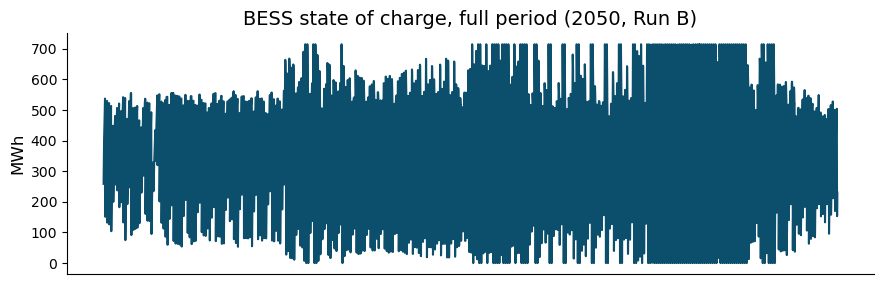

In [20]:

if bess_b is not None:
    charge_mwh = bess_b["dispatch"].clip(upper=0).abs().sum()
    cycles = charge_mwh / bess_b["energy_mwh"] if bess_b["energy_mwh"] else np.nan
    print(f"Full-equivalent cycles over the modelled period: {cycles:.1f}")

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(range(len(bess_b["soc"])), bess_b["soc"].values, color=PALETTE["blue_teal"])
    ax.set_title(f"BESS state of charge, full period ({RUN_YEAR}, Run B)")
    ax.set_ylabel("MWh")
    ax.set_xticks([])
    savefig(fig, "bess_state_of_charge")
    plt.show()


Run A curtailment:
         potential_MWh  actual_MWh  curtailed_MWh  curtailment_pct
onwind       0.116910    0.071517       0.045393        38.827512
solar        0.281081    0.204477       0.076604        27.253413

Run B curtailment:
         potential_MWh  actual_MWh  curtailed_MWh  curtailment_pct
onwind       0.007960    0.004966       0.002994        37.614734
solar        0.023151    0.018389       0.004762        20.569603


saved figures/curtailment_comparison.png


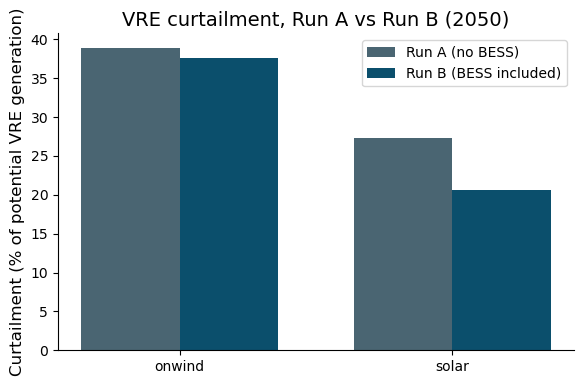

In [21]:

def curtailment_summary(n, carriers=VRE_CARRIERS):
    g = n.generators
    rows = {}
    for c in carriers:
        names = g.index[g.carrier == c]
        if len(names) == 0:
            continue
        cap = g.loc[names, "p_nom_opt"].where(g.loc[names, "p_nom_extendable"], g.loc[names, "p_nom"])
        potential = (n.generators_t.p_max_pu[names] * cap).sum(axis=1)
        actual = n.generators_t.p[names].sum(axis=1)
        curtailed = (potential - actual).clip(lower=0)
        rows[c] = {
            "potential_MWh": potential.sum(), "actual_MWh": actual.sum(),
            "curtailed_MWh": curtailed.sum(),
            "curtailment_pct": 100 * curtailed.sum() / potential.sum() if potential.sum() else np.nan,
        }
    return pd.DataFrame(rows).T

curt_a = curtailment_summary(n_a)
curt_b = curtailment_summary(n_b)
print("Run A curtailment:\n", curt_a)
print("\nRun B curtailment:\n", curt_b)

if len(curt_a) and len(curt_b):
    fig, ax = plt.subplots(figsize=(6, 4))
    idx = curt_a.index
    x = np.arange(len(idx))
    ax.bar(x - 0.18, curt_a["curtailment_pct"], width=0.36, label="Run A (no BESS)", color=PALETTE["slate"])
    ax.bar(x + 0.18, curt_b["curtailment_pct"], width=0.36, label="Run B (BESS included)", color=PALETTE["blue_teal"])
    ax.set_xticks(x); ax.set_xticklabels(idx)
    ax.set_ylabel("Curtailment (% of potential VRE generation)")
    ax.set_title(f"VRE curtailment, Run A vs Run B ({RUN_YEAR})")
    ax.legend()
    savefig(fig, "curtailment_comparison")
    plt.show()


## 14. Energy Mix Over Time

Slide 14. If the model is multi-period, this plots generation share by investment period.
If single-period, it falls back to a within-year monthly aggregation as a proxy, clearly
labelled as such, that is a different claim (seasonal mix, not multi-year evolution) and
should be captioned accordingly on the slide.

saved figures/energy_mix_by_month.png


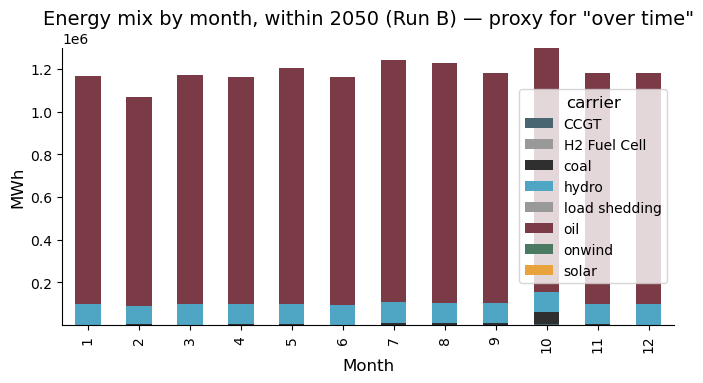

carrier          CCGT  H2 Fuel Cell          coal         hydro  \
snapshot                                                          
1            0.000204      0.000631   1382.303745  95231.999793   
2            0.000191      0.000565   2849.451899  86015.999816   
3            0.000209      0.000622   2157.139434  95231.999794   
4            0.000217      0.000604   5525.118558  92159.999812   
5            0.000215      0.000620   3826.734021  95231.999800   
6            0.000190      0.000593    131.148281  92159.999796   
7          230.092827      0.000629  10759.008456  95231.999830   
8          144.342795      0.000619   9828.900894  95231.999811   
9          192.432061      0.000599  10054.704253  92159.999824   
10        6073.213823      0.000662  53095.011817  95231.999883   
11           0.000275      0.000613   3990.574136  92159.999844   
12           0.000205      0.000610   2170.064429  95231.999794   

carrier   load shedding           oil    onwind     solar  
s

In [22]:

if is_multi_period:
    mix_by_period = gen_b.groupby(level="period").sum()
    fig, ax = plt.subplots(figsize=(7, 4))
    mix_by_period.plot(kind="bar", stacked=True, ax=ax,
                        color=[color_for(c) for c in mix_by_period.columns])
    ax.set_ylabel("MWh (sample snapshots)")
    ax.set_title("Energy mix by investment period (Run B)")
    savefig(fig, "energy_mix_by_period")
    plt.show()
    print(mix_by_period)
else:
    monthly_mix = gen_b.groupby(gen_b.index.month).sum()
    fig, ax = plt.subplots(figsize=(7, 4))
    monthly_mix.plot(kind="bar", stacked=True, ax=ax, color=[color_for(c) for c in monthly_mix.columns])
    ax.set_ylabel("MWh")
    ax.set_xlabel("Month")
    ax.set_title(f"Energy mix by month, within {RUN_YEAR} (Run B) — proxy for \"over time\"")
    savefig(fig, "energy_mix_by_month")
    plt.show()
    print(monthly_mix)


## 14b. Energy Mix Across Modelled Years (actual multi-year pathway)

The block above falls back to a within-year monthly proxy because `n.investment_periods` is
empty, this model's myopic pathway is instead stored as a **separate solved postnetwork file
per year** (`results/<scenario>/postnetworks/..._<year>_...nc`), not as multiple
`investment_periods` inside one file. This loads every year's file for both scenarios and
plots the real year-by-year generation mix, using `generation_by_carrier()` from Section 0 so
StorageUnit (hydro) and Link-based thermal technologies (CCGT/oil/coal) are correctly
included, not just plain Generators.

INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2025_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2030_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2035_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2040_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2045_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


...

INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2035_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2040_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2045_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h_336seg_2050_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


saved figures/energy_mix_across_years.png


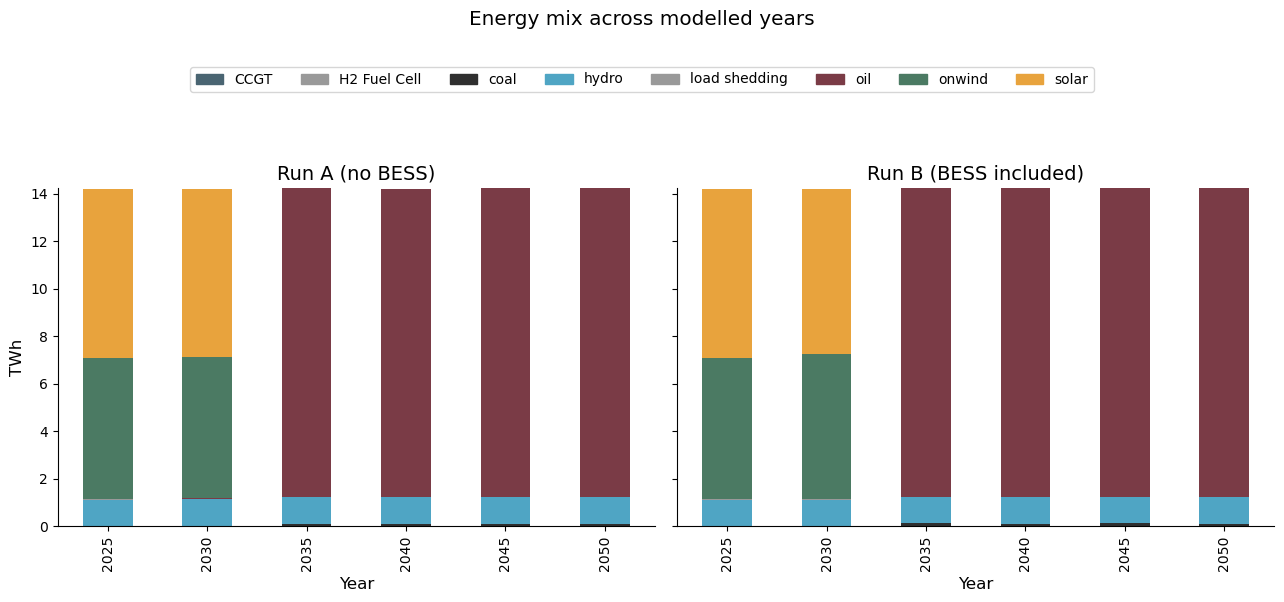

Run A energy mix by year (TWh):
carrier  CCGT  H2 Fuel Cell  coal  hydro  load shedding    oil  onwind  solar
2025     0.00           0.0  0.00   1.12           0.04   0.00    5.95   7.12
2030     0.01           0.0  0.01   1.12           0.00   0.04    5.93   7.12
2035     0.01           0.0  0.10   1.12           0.00  13.00    0.00   0.00
2040     0.01           0.0  0.10   1.12           0.00  13.00    0.00   0.00
2045     0.01           0.0  0.10   1.12           0.00  13.00    0.00   0.00
2050     0.01           0.0  0.10   1.12           0.00  13.00    0.00   0.00

Run B energy mix by year (TWh):
carrier  CCGT  H2 Fuel Cell  coal  hydro  load shedding    oil  onwind  solar
2025     0.00           0.0  0.00   1.12           0.04   0.00    5.94   7.13
2030     0.00           0.0  0.00   1.12           0.04   0.00    6.08   6.99
2035     0.01           0.0  0.11   1.12           0.00  13.00    0.00   0.00
2040     0.01           0.0  0.10   1.12           0.00  13.01    0.00   0.00

In [23]:

# --- Energy mix across all modelled years (separate postnetwork file per year) ---
import re

YEARS = [2025, 2030, 2035, 2040, 2045, 2050]

def _year_paths(example_path):
    '''Given one RUN_*_PATH, return (folder, filename_pattern_with_{year}_placeholder).'''
    p = Path(example_path)
    pattern = re.sub(r"_(20[2-6]\d)_", "_{year}_", p.name)
    return p.parent, pattern

def load_energy_mix_by_year(example_path, years=YEARS):
    folder, pattern = _year_paths(example_path)
    mix = {}
    for year in years:
        path = folder / pattern.format(year=year)
        if not path.exists():
            print(f"missing: {path}")
            continue
        n_year = pypsa.Network(str(path))
        mix[year] = generation_by_carrier(n_year).sum()
    return pd.DataFrame(mix).T.fillna(0)  # index=year, columns=carrier

mix_a_by_year = load_energy_mix_by_year(RUN_A_PATH)
mix_b_by_year = load_energy_mix_by_year(RUN_B_PATH)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, mix, title in [(axes[0], mix_a_by_year, "Run A (no BESS)"),
                        (axes[1], mix_b_by_year, "Run B (BESS included)")]:
    mix_twh = mix / 1e6  # MWh -> TWh
    mix_twh.plot(kind="bar", stacked=True, ax=ax, color=[color_for(c) for c in mix_twh.columns], legend=False)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("TWh")

all_labels = list(dict.fromkeys(list(mix_a_by_year.columns) + list(mix_b_by_year.columns)))
handles = [plt.Rectangle((0, 0), 1, 1, color=color_for(c)) for c in all_labels]
fig.legend(handles, all_labels, loc="upper center", ncol=len(all_labels), bbox_to_anchor=(0.5, 1.1))
fig.suptitle("Energy mix across modelled years", y=1.2)
savefig(fig, "energy_mix_across_years")
plt.show()

print("Run A energy mix by year (TWh):")
print((mix_a_by_year / 1e6).round(2))
print("\nRun B energy mix by year (TWh):")
print((mix_b_by_year / 1e6).round(2))


## 15. Network & Congestion Results

Slide 15.

In [24]:

if len(n_b.lines):
    def line_loading(n):
        s_nom = n.lines.s_nom_opt.where(n.lines.s_nom_extendable, n.lines.s_nom)
        return n.lines_t.p0.abs().div(s_nom, axis=1)

    loading_a = line_loading(n_a)
    loading_b = line_loading(n_b)
    print("Congestion hours (>=99% loading) per line, Run A:\n", (loading_a >= 0.99).sum())
    print("\nCongestion hours (>=99% loading) per line, Run B:\n", (loading_b >= 0.99).sum())

    price_compare = pd.DataFrame({"Run A": n_a.buses_t.marginal_price.mean(),
                                   "Run B": n_b.buses_t.marginal_price.mean()})
    print("\nMean nodal price by bus:\n", price_compare)
else:
    print("No Lines in this network, skipping.")


Congestion hours (>=99% loading) per line, Run A:
 Line
0                                 0
1                                 0
10                                0
11                                0
12                                0
13                                0
14                                0
15                                0
16                                0
17                                0
18                                0
19                                0
2                                 0
20                                0
21                                0
22                                0
23                                0
24                                0
25                                0
3                                 0
4                                 0
5                                 0
6                                 0
7                                 0
8                                 0
9                                 0
lines ne

## 16. Emissions

Slide 16.

In [25]:

def co2_atmosphere_emissions(n):
    '''Total tCO2 emitted to atmosphere over the modelled period, read directly from the
    "co2 atmosphere" Store's state of charge, the model's own CO2 balance from solving,
    rather than recomputed from an assumed emission-factor table.'''
    e = n.stores_t.e["co2 atmosphere"]
    return e.iloc[-1] - e.iloc[0]

def co2_emissions_by_link_carrier(n):
    '''Breaks the atmosphere total down by the Link carrier that emitted it (e.g. CCGT, oil,
    coal, SMR), by summing flow into whichever bus position ("bus1"/"bus2"/"bus3") equals
    "co2 atmosphere" for each link, weighted by that position's efficiency. CO2 routed to
    "co2 stored" instead (e.g. captured by SMR CC) is correctly excluded, it never reaches
    the atmosphere bus. Keyed by the conversion technology (CCGT, SMR, ...), not by raw fuel,
    since the same fuel (gas) can be converted via multiple technologies with different
    emission factors.'''
    total = pd.Series(dtype=float)
    for bus_col, eff_col in [("bus1", "efficiency"), ("bus2", "efficiency2"), ("bus3", "efficiency3")]:
        if bus_col not in n.links.columns or eff_col not in n.links.columns:
            continue
        mask = n.links[bus_col] == "co2 atmosphere"
        if not mask.any():
            continue
        names = n.links.index[mask]
        flow = n.links_t.p0[names].mul(n.links.loc[names, eff_col], axis=1).sum(axis=0)
        total = total.add(flow.groupby(n.links.loc[names, "carrier"]).sum(), fill_value=0)
    return total.sort_values(ascending=False)

if "co2 atmosphere" in n_a.stores.index and "co2 atmosphere" in n_b.stores.index:
    total_a = co2_atmosphere_emissions(n_a)
    total_b = co2_atmosphere_emissions(n_b)
    em_a = co2_emissions_by_link_carrier(n_a)
    em_b = co2_emissions_by_link_carrier(n_b)

    print(f"Total emissions, Run A: {total_a:,.0f} tCO2 (link breakdown reconciles to {em_a.sum():,.0f})")
    print(f"Total emissions, Run B: {total_b:,.0f} tCO2 (link breakdown reconciles to {em_b.sum():,.0f})")
    print(f"\nTotal emissions avoided: {total_a - total_b:,.0f} tCO2")

    print("\nEmissions by carrier, Run A (tCO2):\n", em_a)
    print("\nEmissions by carrier, Run B (tCO2):\n", em_b)

    total_gen_a = generation_by_carrier(n_a).sum().sum()
    total_gen_b = generation_by_carrier(n_b).sum().sum()
    print(f"\nEmissions intensity, Run A: {total_a / total_gen_a:.3f} tCO2/MWh")
    print(f"Emissions intensity, Run B: {total_b / total_gen_b:.3f} tCO2/MWh")

    if CARBON_PRICE:
        print(f"Emissions value avoided at {CARBON_PRICE}/tCO2: {(total_a - total_b) * CARBON_PRICE:,.0f}")
else:
    print("No 'co2 atmosphere' store found in one or both networks, this model doesn't track CO2 "
          "this way, fall back to carrier-level co2_emissions (n.carriers) x dispatch instead.")


Total emissions, Run A: 9,648,139 tCO2 (link breakdown reconciles to 9,648,920)
Total emissions, Run B: 9,654,110 tCO2 (link breakdown reconciles to 9,654,906)

Total emissions avoided: -5,971 tCO2

Emissions by carrier, Run A (tCO2):
 carrier
oil         9.551555e+06
coal        9.481100e+04
CCGT        2.553903e+03
SMR         1.610286e-02
co2 vent    1.414642e-02
SMR CC      1.579253e-03
dtype: float64

Emissions by carrier, Run B (tCO2):
 carrier
oil         9.552857e+06
coal        9.985773e+04
CCGT        2.191227e+03
SMR         1.414163e-03
co2 vent    1.236775e-03
SMR CC      1.380460e-04
dtype: float64

Emissions intensity, Run A: 0.678 tCO2/MWh
Emissions intensity, Run B: 0.678 tCO2/MWh


## 17. Reliability

Slide 17. Only meaningful if your model represents scarcity, e.g. via a high-marginal-cost
load-shedding generator, adjust `SLACK_CARRIER` to match your setup.

In [26]:
SLACK_CARRIER = "load shedding"  # TODO: set to match your model, or None if scarcity isn't modelled

def unserved_energy(n, slack_carrier=SLACK_CARRIER):
    if slack_carrier is None or slack_carrier not in n.generators.carrier.values:
        return None
    names = n.generators.index[n.generators.carrier == slack_carrier]
    return n.generators_t.p[names].sum(axis=1)

ue_a = unserved_energy(n_a)
ue_b = unserved_energy(n_b)
if ue_a is not None:
    print(f"Run A unserved energy: {ue_a.sum():,.1f} MWh, valued at VoLL: {ue_a.sum() * VOLL:,.0f}")
    print(f"Run B unserved energy: {ue_b.sum():,.1f} MWh, valued at VoLL: {ue_b.sum() * VOLL:,.0f}")
    print(f"Avoided unserved energy value: {(ue_a.sum() - ue_b.sum()) * VOLL:,.0f}")
else:
    print("No slack/load-shedding carrier found, scarcity is not represented in this model.")


Run A unserved energy: 0.0 MWh, valued at VoLL: 0
Run B unserved energy: 0.0 MWh, valued at VoLL: 0
Avoided unserved energy value: 0


## 18. Map: Generation + Storage + Transmission in Final Year

Slide 18. Uses the final investment period if multi-period, otherwise the single solved
state (which already represents "the future" relative to today, for a single-horizon
expansion run).

saved figures/system_map_final_year.png


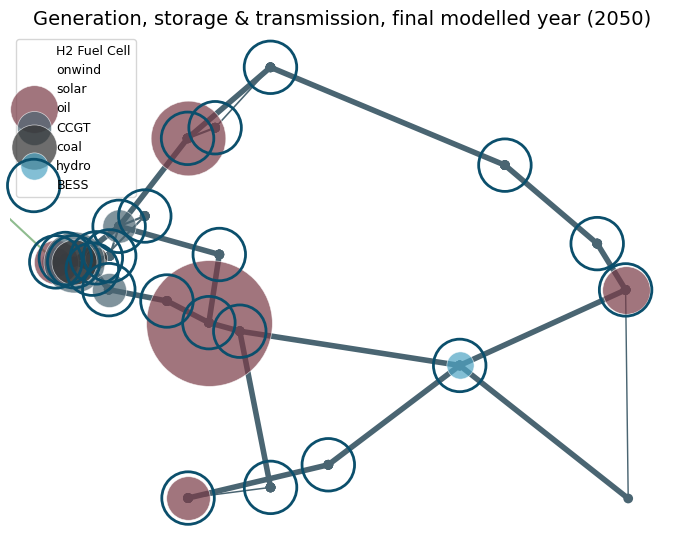

In [27]:

if is_multi_period:
    final_period = max(n_b.investment_periods)
    active_gens = n_b.generators[n_b.generators.build_year <= final_period]
    active_su = n_b.storage_units[n_b.storage_units.build_year <= final_period]
    active_links = n_b.links[n_b.links.build_year <= final_period]
    map_year_label = final_period
else:
    active_gens = n_b.generators
    active_su = n_b.storage_units
    active_links = n_b.links
    map_year_label = RUN_YEAR
active_gens = active_gens[~active_gens.carrier.isin(NON_PHYSICAL_CARRIERS)]
active_gens = active_gens[n_b.buses["carrier"].reindex(active_gens["bus"]).values == "AC"]

cap_final = active_gens.p_nom_opt.where(active_gens.p_nom_extendable, active_gens.p_nom)
cap_by_bus_carrier = cap_final.groupby([active_gens.bus, active_gens.carrier]).sum()

# Include StorageUnit-based capacity (e.g. hydro), otherwise silently absent just because
# it isn't a Generator.
if len(active_su):
    su_cap_final = active_su.p_nom_opt.where(active_su.p_nom_extendable, active_su.p_nom)
    su_cap_by_bus_carrier = su_cap_final.groupby([active_su.bus, active_su.carrier]).sum()
    cap_by_bus_carrier = cap_by_bus_carrier.add(su_cap_by_bus_carrier, fill_value=0)

# Include the AC-output conversion Links (e.g. CCGT/oil/coal power plants): their real
# electrical capacity lives here, not on the fuel-supply Generator (see Section 0).
# NOTE: the grouper is renamed "bus1" -> "bus", otherwise .add() below treats the two
# differently-named MultiIndex levels as distinct and creates a 3-level index instead of
# aligning by (bus, carrier).
is_ac_output = n_b.buses["carrier"].reindex(active_links["bus1"]).values == "AC"
is_bess_link = active_links["carrier"].isin(["battery charger", "battery discharger"])
active_elink = active_links[is_ac_output & ~is_bess_link]
if len(active_elink):
    el_cap_final = active_elink.p_nom_opt.where(active_elink.p_nom_extendable, active_elink.p_nom)
    el_cap_by_bus_carrier = el_cap_final.groupby([active_elink.bus1.rename("bus"), active_elink.carrier]).sum()
    cap_by_bus_carrier = cap_by_bus_carrier.add(el_cap_by_bus_carrier, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 7))
line_cap = n_b.lines.s_nom_opt.where(n_b.lines.s_nom_extendable, n_b.lines.s_nom)
line_widths = 1 + 3 * (line_cap / line_cap.max()) if len(line_cap) and line_cap.max() > 0 else 1.5
n_b.plot(ax=ax, geomap=False, bus_sizes=0.002, bus_colors=PALETTE["slate"],
         line_widths=line_widths, line_colors=PALETTE["slate"])
ax.set_xlim(*geo_bounds(n_b)[0])
ax.set_ylim(*geo_bounds(n_b)[1])

for (bus, carrier), capval in cap_by_bus_carrier.items():
    if bus in n_b.buses.index and capval > 0:
        x, y = n_b.buses.loc[bus, ["x", "y"]]
        ax.scatter([x], [y], s=capval * 3, color=color_for(carrier), alpha=0.7,
                   edgecolors="white", linewidths=0.5, zorder=5, label=carrier)

if bess_b is not None:
    for bus in bess_b["buses"]:
        if bus in n_b.buses.index:
            x, y = n_b.buses.loc[bus, ["x", "y"]]
            ax.scatter([x], [y], s=bess_b["energy_mwh"] * 2, facecolors="none",
                       edgecolors=PALETTE["blue_teal"], linewidths=2, zorder=6, label="BESS")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=9)
ax.set_title(f"Generation, storage & transmission, final modelled year ({map_year_label})")
savefig(fig, "system_map_final_year")
plt.show()


## 19. Assumptions & Limitations

Slide 19.

- **Single weather year:** if either run uses one weather year, inter-annual VRE variability
  is not captured, flag this as a limitation on curtailment, siting, and reliability results.
- **Myopic vs perfect foresight:** stated explicitly in Section 2, restate here for the slide.
- **Sensitivity / Monte Carlo:** deferred for now, note this as a scope decision, EMA Workbench
  flagged as a discussion-chapter framing for robustness to deep uncertainty if reviewers press
  on it.
- **Existing BESS (Tobène & Walo):** confirmed excluded-only in Run A. A fixed-in-both
  variant, testing only *additional* BESS beyond what's committed, would be a separate pair
  of runs.
